In [61]:
import pandas as pd
import numpy as np

file_path = "../data/processed/cleaned_transactions.csv"

df = pd.read_csv(file_path)

df.head()

,Transaction ID,Total Spent,Location,Transaction Date,Province,Item,Location_missing_flag,Province_missing_flag
0,TXN_9687814,7.0,In-store,2023-09-28,British Columbia,Coffee,0,0
1,TXN_7002925,10.0,Takeaway,2023-05-02,Newfoundland and Labrador,Refresher,1,0
2,TXN_7668262,2.0,In-store,2023-11-27,British Columbia,Donut,0,0
3,TXN_9390285,3.5,Takeaway,2023-05-11,Newfoundland and Labrador,Coffee,0,0
4,TXN_7321503,3.0,Takeaway,2023-09-15,British Columbia,Tea,0,0


In [62]:
# Drop Transaction ID column
df = df.drop(columns=["Transaction ID"])

# Verify
df.head()

,Total Spent,Location,Transaction Date,Province,Item,Location_missing_flag,Province_missing_flag
0,7.0,In-store,2023-09-28,British Columbia,Coffee,0,0
1,10.0,Takeaway,2023-05-02,Newfoundland and Labrador,Refresher,1,0
2,2.0,In-store,2023-11-27,British Columbia,Donut,0,0
3,3.5,Takeaway,2023-05-11,Newfoundland and Labrador,Coffee,0,0
4,3.0,Takeaway,2023-09-15,British Columbia,Tea,0,0


In [63]:
# Make sure Transaction Date is datetime
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Create date-only column
df["Date"] = df["Transaction Date"].dt.date

# Count sales per Date + Province + Item
same_item_sales_per_region = (
    df
    .groupby(["Date", "Province", "Item"])
    .size()
    .reset_index(name="sales_count")
)

# Keep only cases where the same item was sold more than once
multiple_sales_same_item = same_item_sales_per_region[
    same_item_sales_per_region["sales_count"] > 1
]

multiple_sales_same_item.head(20)

,Date,Province,Item,sales_count
0,2023-01-01,British Columbia,Coffee,2
4,2023-01-01,Manitoba,Sandwich,2
6,2023-01-01,Newfoundland and Labrador,Tea,3
10,2023-01-02,British Columbia,Cookie,2
14,2023-01-02,British Columbia,Salad,3
15,2023-01-02,British Columbia,Sandwich,3
16,2023-01-02,British Columbia,Tea,2
17,2023-01-02,Manitoba,Coffee,2
18,2023-01-02,Manitoba,Donut,2
21,2023-01-02,Manitoba,Tea,2


In [64]:
# Make a copy for time-series feature engineering
df_ts = df.copy()

# Convert Transaction Date to datetime
df_ts["Transaction Date"] = pd.to_datetime(df_ts["Transaction Date"], errors="coerce")

# Check if any dates failed to convert
print("Missing / invalid dates:", df_ts["Transaction Date"].isna().sum())

# Drop rows with invalid dates if any exist
df_ts = df_ts.dropna(subset=["Transaction Date"])

# Sort chronologically
df_ts = df_ts.sort_values("Transaction Date").reset_index(drop=True)

df_ts.head()

Missing / invalid dates: 0


,Total Spent,Location,Transaction Date,Province,Item,Location_missing_flag,Province_missing_flag,Date
0,6.0,Takeaway,2023-01-01,Newfoundland and Labrador,Tea,0,0,2023-01-01
1,3.5,Takeaway,2023-01-01,British Columbia,Coffee,0,0,2023-01-01
2,14.0,In-store,2023-01-01,Saskatchewan,Coffee,0,0,2023-01-01
3,9.0,In-store,2023-01-01,Newfoundland and Labrador,Tea,0,0,2023-01-01
4,16.0,In-store,2023-01-01,Manitoba,Sandwich,0,0,2023-01-01


In [65]:
df_ts["Date"] = df_ts["Transaction Date"].dt.normalize()

df_ts.head()

,Total Spent,Location,Transaction Date,Province,Item,Location_missing_flag,Province_missing_flag,Date
0,6.0,Takeaway,2023-01-01,Newfoundland and Labrador,Tea,0,0,2023-01-01
1,3.5,Takeaway,2023-01-01,British Columbia,Coffee,0,0,2023-01-01
2,14.0,In-store,2023-01-01,Saskatchewan,Coffee,0,0,2023-01-01
3,9.0,In-store,2023-01-01,Newfoundland and Labrador,Tea,0,0,2023-01-01
4,16.0,In-store,2023-01-01,Manitoba,Sandwich,0,0,2023-01-01


In [66]:
print("Start date:", df_ts["Date"].min())
print("End date:", df_ts["Date"].max())
print("Number of unique dates:", df_ts["Date"].nunique())

Start date: 2023-01-01 00:00:00
End date: 2023-12-31 00:00:00
Number of unique dates: 365


In [67]:
all_dates = pd.date_range(start="2023-01-01", end="2023-12-31", freq="D")

print("Expected number of dates:", len(all_dates))

Expected number of dates: 365


In [68]:
provinces = sorted(df_ts["Province"].dropna().unique())
items = sorted(df_ts["Item"].dropna().unique())

print("Number of provinces:", len(provinces))
print("Number of items:", len(items))

print("Provinces:", provinces)
print("Items:", items)

Number of provinces: 5
Number of items: 8
Provinces: ['British Columbia', 'Manitoba', 'Newfoundland and Labrador', 'Ontario', 'Saskatchewan']
Items: ['Coffee', 'Cookie', 'Donut', 'Juice', 'Refresher', 'Salad', 'Sandwich', 'Tea']


In [69]:
daily_sales = (
    df_ts
    .groupby(["Date", "Province", "Item"], as_index=False)
    .agg(
        total_spent=("Total Spent", "sum"),
        transaction_count=("Total Spent", "size"),
        avg_transaction_value=("Total Spent", "mean"),
        location_missing_count=("Location_missing_flag", "sum"),
        province_missing_count=("Province_missing_flag", "sum")
    )
)

daily_sales.head(20)

,Date,Province,Item,total_spent,transaction_count,avg_transaction_value,location_missing_count,province_missing_count
0,2023-01-01,British Columbia,Coffee,10.5,2,5.25,0,0
1,2023-01-01,British Columbia,Donut,10.0,1,10.00,0,0
2,2023-01-01,British Columbia,Sandwich,16.0,1,16.00,1,0
3,2023-01-01,Manitoba,Coffee,3.5,1,3.50,0,0
4,2023-01-01,Manitoba,Sandwich,24.0,2,12.00,0,0
5,2023-01-01,Newfoundland and Labrador,Refresher,10.0,1,10.00,0,0
6,2023-01-01,Newfoundland and Labrador,Tea,27.0,3,9.00,0,0
7,2023-01-01,Saskatchewan,Coffee,14.0,1,14.00,0,0
8,2023-01-01,Saskatchewan,Refresher,5.0,1,5.00,0,0
9,2023-01-02,British Columbia,Coffee,3.5,1,3.50,0,0


In [70]:
full_index = pd.MultiIndex.from_product(
    [all_dates, provinces, items],
    names=["Date", "Province", "Item"]
)

full_panel = full_index.to_frame(index=False)

full_panel.head(20)

,Date,Province,Item
0,2023-01-01,British Columbia,Coffee
1,2023-01-01,British Columbia,Cookie
2,2023-01-01,British Columbia,Donut
3,2023-01-01,British Columbia,Juice
4,2023-01-01,British Columbia,Refresher
5,2023-01-01,British Columbia,Salad
6,2023-01-01,British Columbia,Sandwich
7,2023-01-01,British Columbia,Tea
8,2023-01-01,Manitoba,Coffee
9,2023-01-01,Manitoba,Cookie


In [71]:
df_panel = full_panel.merge(
    daily_sales,
    on=["Date", "Province", "Item"],
    how="left"
)

df_panel.head(20)

,Date,Province,Item,total_spent,transaction_count,avg_transaction_value,location_missing_count,province_missing_count
0,2023-01-01,British Columbia,Coffee,10.5,2.0,5.25,0.0,0.0
1,2023-01-01,British Columbia,Cookie,NaN,NaN,NaN,NaN,NaN
2,2023-01-01,British Columbia,Donut,10.0,1.0,10.00,0.0,0.0
3,2023-01-01,British Columbia,Juice,NaN,NaN,NaN,NaN,NaN
4,2023-01-01,British Columbia,Refresher,NaN,NaN,NaN,NaN,NaN
5,2023-01-01,British Columbia,Salad,NaN,NaN,NaN,NaN,NaN
6,2023-01-01,British Columbia,Sandwich,16.0,1.0,16.00,1.0,0.0
7,2023-01-01,British Columbia,Tea,NaN,NaN,NaN,NaN,NaN
8,2023-01-01,Manitoba,Coffee,3.5,1.0,3.50,0.0,0.0
9,2023-01-01,Manitoba,Cookie,NaN,NaN,NaN,NaN,NaN


In [72]:
# Flag whether this Province-Item-Date combination existed in the original data
df_panel["had_transaction"] = df_panel["total_spent"].notna().astype(int)

# Fill missing numeric values
df_panel["total_spent"] = df_panel["total_spent"].fillna(0)
df_panel["transaction_count"] = df_panel["transaction_count"].fillna(0)
df_panel["avg_transaction_value"] = df_panel["avg_transaction_value"].fillna(0)
df_panel["location_missing_count"] = df_panel["location_missing_count"].fillna(0)
df_panel["province_missing_count"] = df_panel["province_missing_count"].fillna(0)

# Convert count columns to integers
count_cols = [
    "transaction_count",
    "location_missing_count",
    "province_missing_count",
    "had_transaction"
]

df_panel[count_cols] = df_panel[count_cols].astype(int)

df_panel.head(20)

,Date,Province,Item,total_spent,transaction_count,avg_transaction_value,location_missing_count,province_missing_count,had_transaction
0,2023-01-01,British Columbia,Coffee,10.5,2,5.25,0,0,1
1,2023-01-01,British Columbia,Cookie,0.0,0,0.00,0,0,0
2,2023-01-01,British Columbia,Donut,10.0,1,10.00,0,0,1
3,2023-01-01,British Columbia,Juice,0.0,0,0.00,0,0,0
4,2023-01-01,British Columbia,Refresher,0.0,0,0.00,0,0,0
5,2023-01-01,British Columbia,Salad,0.0,0,0.00,0,0,0
6,2023-01-01,British Columbia,Sandwich,16.0,1,16.00,1,0,1
7,2023-01-01,British Columbia,Tea,0.0,0,0.00,0,0,0
8,2023-01-01,Manitoba,Coffee,3.5,1,3.50,0,0,1
9,2023-01-01,Manitoba,Cookie,0.0,0,0.00,0,0,0


In [73]:
expected_rows = len(all_dates) * len(provinces) * len(items)
actual_rows = len(df_panel)

print("Expected rows:", expected_rows)
print("Actual rows:", actual_rows)
print("Match:", expected_rows == actual_rows)

Expected rows: 14600
Actual rows: 14600
Match: True


In [74]:
df_panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    14600 non-null  datetime64[us]
 1   Province                14600 non-null  str           
 2   Item                    14600 non-null  str           
 3   total_spent             14600 non-null  float64       
 4   transaction_count       14600 non-null  int64         
 5   avg_transaction_value   14600 non-null  float64       
 6   location_missing_count  14600 non-null  int64         
 7   province_missing_count  14600 non-null  int64         
 8   had_transaction         14600 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(4), str(2)
memory usage: 1.0 MB


In [75]:
# Make a copy of your Province-Item-Date panel
df_features = df_panel.copy()

# Make sure Date is datetime
df_features["Date"] = pd.to_datetime(df_features["Date"])

# Sort chronologically
df_features = df_features.sort_values(
    ["Date", "Province", "Item"]
).reset_index(drop=True)

# Time-series / calendar features
df_features["day_of_week"] = df_features["Date"].dt.dayofweek
df_features["day_of_month"] = df_features["Date"].dt.day
df_features["day_of_year"] = df_features["Date"].dt.dayofyear
df_features["is_weekend"] = df_features["day_of_week"].isin([5, 6]).astype(int)
df_features["quarter"] = df_features["Date"].dt.quarter
df_features["month"] = df_features["Date"].dt.month

df_features.tail(50)

,Date,Province,Item,total_spent,transaction_count,avg_transaction_value,location_missing_count,province_missing_count,had_transaction,day_of_week,day_of_month,day_of_year,is_weekend,quarter,month
14550,2023-12-30,Ontario,Sandwich,0.0,0,0.00,0,0,0,5,30,364,1,4,12
14551,2023-12-30,Ontario,Tea,0.0,0,0.00,0,0,0,5,30,364,1,4,12
14552,2023-12-30,Saskatchewan,Coffee,7.0,1,7.00,0,0,1,5,30,364,1,4,12
14553,2023-12-30,Saskatchewan,Cookie,0.0,0,0.00,0,0,0,5,30,364,1,4,12
14554,2023-12-30,Saskatchewan,Donut,0.0,0,0.00,0,0,0,5,30,364,1,4,12
14555,2023-12-30,Saskatchewan,Juice,0.0,0,0.00,0,0,0,5,30,364,1,4,12
14556,2023-12-30,Saskatchewan,Refresher,0.0,0,0.00,0,0,0,5,30,364,1,4,12
14557,2023-12-30,Saskatchewan,Salad,0.0,0,0.00,0,0,0,5,30,364,1,4,12
14558,2023-12-30,Saskatchewan,Sandwich,0.0,0,0.00,0,0,0,5,30,364,1,4,12
14559,2023-12-30,Saskatchewan,Tea,0.0,0,0.00,0,0,0,5,30,364,1,4,12


In [76]:
# Use your feature/panel dataframe
df_sales_trend = df_features.copy()

# Make sure Date is datetime
df_sales_trend["Date"] = pd.to_datetime(df_sales_trend["Date"])

# Aggregate total sales per province per day
province_daily_sales = (
    df_sales_trend
    .groupby(["Date", "Province"], as_index=False)
    .agg(total_sales=("total_spent", "sum"))
)

province_daily_sales.head()

,Date,Province,total_sales
0,2023-01-01,British Columbia,36.5
1,2023-01-01,Manitoba,27.5
2,2023-01-01,Newfoundland and Labrador,37.0
3,2023-01-01,Ontario,0.0
4,2023-01-01,Saskatchewan,19.0


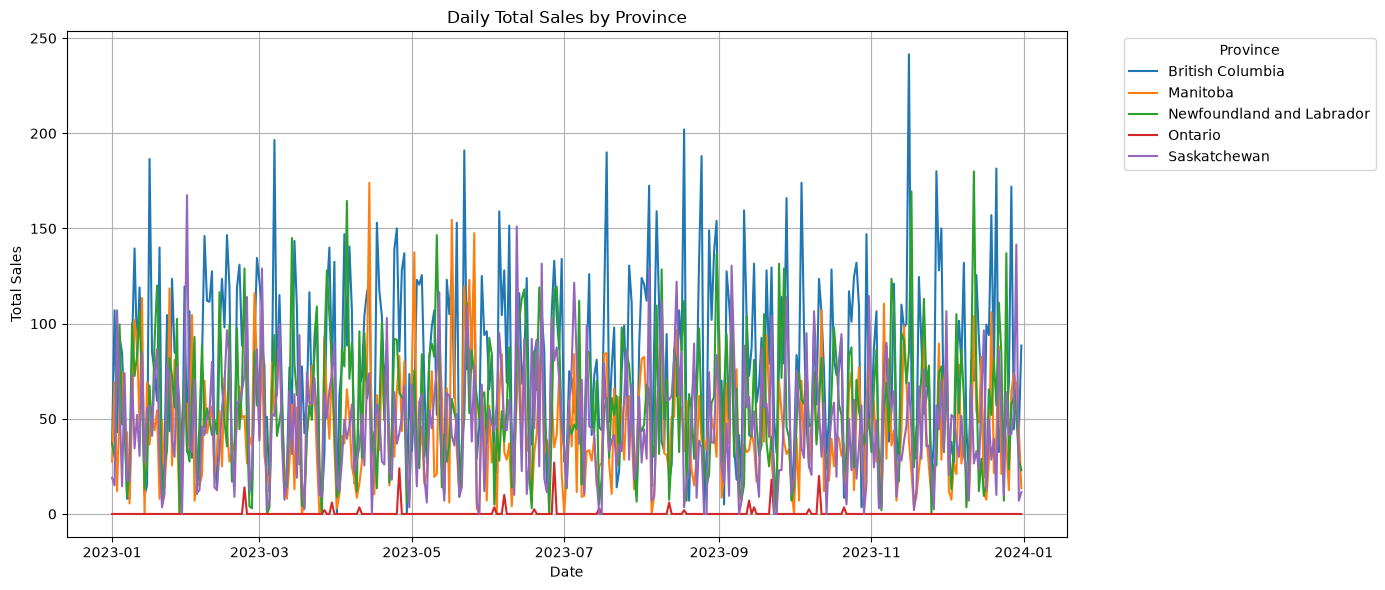

In [77]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))

for province in province_daily_sales["Province"].unique():
    province_data = province_daily_sales[
        province_daily_sales["Province"] == province
    ]

    plt.plot(
        province_data["Date"],
        province_data["total_sales"],
        label=province
    )

plt.title("Daily Total Sales by Province")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend(title="Province", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

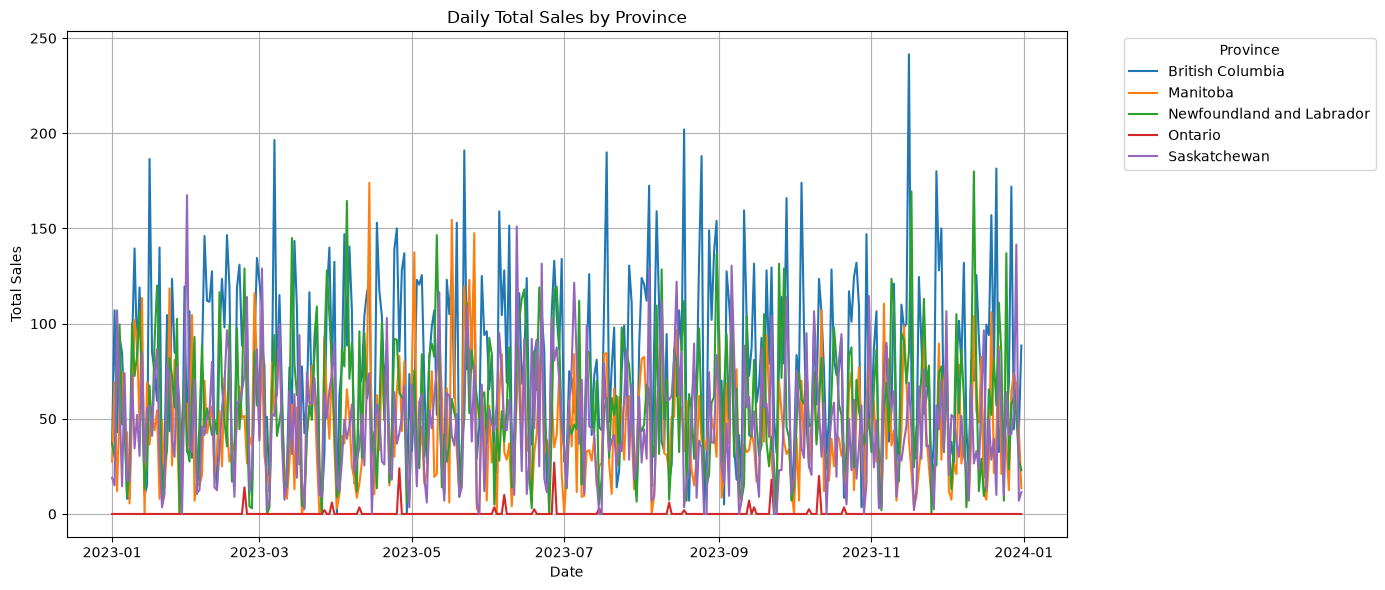

In [78]:
plt.figure(figsize=(14, 6))

for province in province_daily_sales["Province"].unique():
    province_data = province_daily_sales[
        province_daily_sales["Province"] == province
    ]

    plt.plot(
        province_data["Date"],
        province_data["total_sales"],
        label=province
    )

plt.title("Daily Total Sales by Province")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend(title="Province", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# Start from your panel / feature dataframe
df_bc = df_features.copy()

# Make sure Date is datetime
df_bc["Date"] = pd.to_datetime(df_bc["Date"])

# Filter for British Columbia
df_bc = df_bc[df_bc["Province"] == "Newfoundland and Labrador"]

# Aggregate total sales per day across all items
bc_daily_sales = (
    df_bc
    .groupby("Date", as_index=False)
    .agg(total_sales=("total_spent", "sum"))
)

bc_daily_sales.head()

,Date,total_sales
0,2023-01-01,37.0
1,2023-01-02,30.0
2,2023-01-03,70.0
3,2023-01-04,99.5
4,2023-01-05,47.0


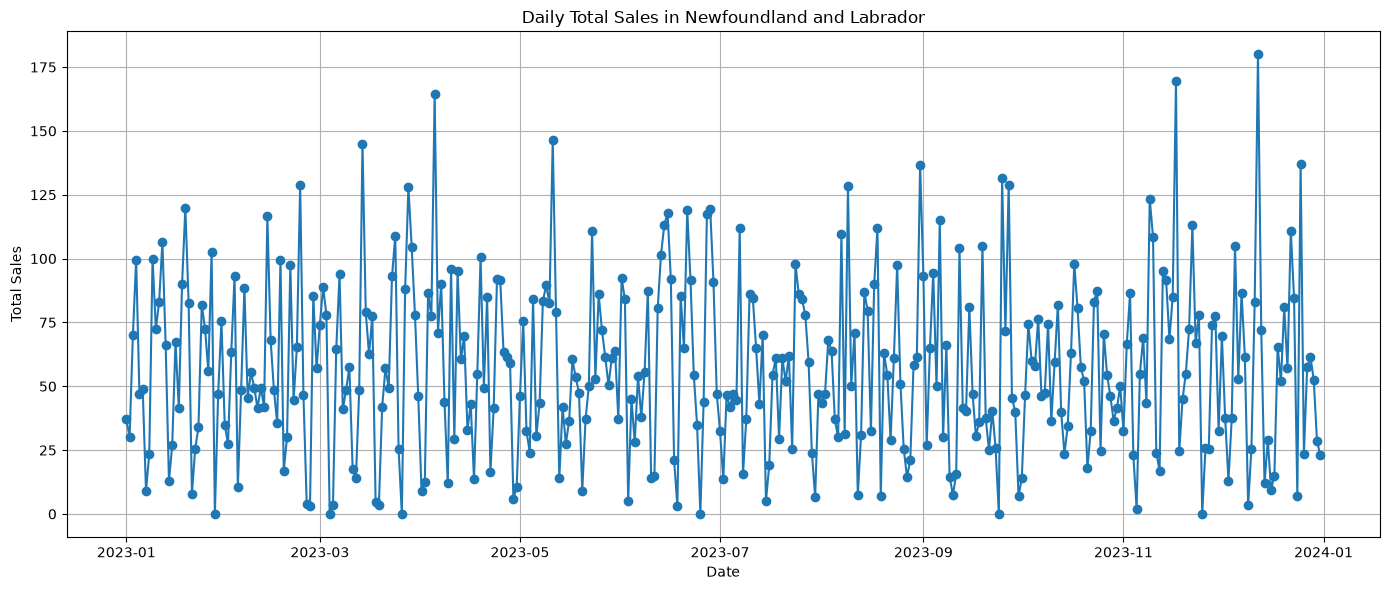

In [80]:
plt.figure(figsize=(14, 6))

plt.plot(
    bc_daily_sales["Date"],
    bc_daily_sales["total_sales"],
    marker="o"
)

plt.title("Daily Total Sales in Newfoundland and Labrador")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

In [81]:
# Make sure Date is datetime
bc_daily_sales["Date"] = pd.to_datetime(bc_daily_sales["Date"])

# Create day of week features
bc_daily_sales["day_of_week"] = bc_daily_sales["Date"].dt.dayofweek
bc_daily_sales["day_name"] = bc_daily_sales["Date"].dt.day_name()

# Compute average sales by day of week
bc_avg_sales_by_day = (
    bc_daily_sales
    .groupby(["day_of_week", "day_name"], as_index=False)
    .agg(
        average_daily_sales=("total_sales", "mean"),
        total_sales=("total_sales", "sum"),
        number_of_days=("Date", "count")
    )
    .sort_values("day_of_week")
)

bc_avg_sales_by_day

,day_of_week,day_name,average_daily_sales,total_sales,number_of_days
0,0,Monday,66.836538,3475.5,52
1,1,Tuesday,72.461538,3768.0,52
2,2,Wednesday,70.586538,3670.5,52
3,3,Thursday,70.153846,3648.0,52
4,4,Friday,73.086538,3800.5,52
5,5,Saturday,22.365385,1163.0,52
6,6,Sunday,25.311321,1341.5,53


In [82]:
# Make sure Date is datetime
df_features["Date"] = pd.to_datetime(df_features["Date"])

# Sort before creating lag features
df_features = df_features.sort_values(
    ["Province", "Item", "Date"]
).reset_index(drop=True)

# Create lag features within each Province-Item time series
df_features["total_spent_lag_1"] = (
    df_features
    .groupby(["Province", "Item"])["total_spent"]
    .shift(1)
)

df_features["total_spent_lag_7"] = (
    df_features
    .groupby(["Province", "Item"])["total_spent"]
    .shift(7)
)

df_features.head()

,Date,Province,Item,total_spent,transaction_count,avg_transaction_value,location_missing_count,province_missing_count,had_transaction,day_of_week,day_of_month,day_of_year,is_weekend,quarter,month,total_spent_lag_1,total_spent_lag_7
0,2023-01-01,British Columbia,Coffee,10.5,2,5.25,0,0,1,6,1,1,1,1,1,NaN,NaN
1,2023-01-02,British Columbia,Coffee,3.5,1,3.50,0,0,1,0,2,2,0,1,1,10.5,NaN
2,2023-01-03,British Columbia,Coffee,21.0,3,7.00,0,0,1,1,3,3,0,1,1,3.5,NaN
3,2023-01-04,British Columbia,Coffee,14.0,2,7.00,0,0,1,2,4,4,0,1,1,21.0,NaN
4,2023-01-05,British Columbia,Coffee,17.5,1,17.50,1,0,1,3,5,5,0,1,1,14.0,NaN


In [83]:
# Create missing-history flags
df_features["total_spent_lag_1_missing_flag"] = (
    df_features["total_spent_lag_1"].isna().astype(int)
)

df_features["total_spent_lag_7_missing_flag"] = (
    df_features["total_spent_lag_7"].isna().astype(int)
)

# Fill missing lag values with 0
df_features["total_spent_lag_1"] = df_features["total_spent_lag_1"].fillna(0)
df_features["total_spent_lag_7"] = df_features["total_spent_lag_7"].fillna(0)

In [84]:
df_features[
    ["Date", "Province", "Item", "total_spent", "total_spent_lag_1", "total_spent_lag_7"]
].head(20)

,Date,Province,Item,total_spent,total_spent_lag_1,total_spent_lag_7
0,2023-01-01,British Columbia,Coffee,10.5,0.0,0.0
1,2023-01-02,British Columbia,Coffee,3.5,10.5,0.0
2,2023-01-03,British Columbia,Coffee,21.0,3.5,0.0
3,2023-01-04,British Columbia,Coffee,14.0,21.0,0.0
4,2023-01-05,British Columbia,Coffee,17.5,14.0,0.0
5,2023-01-06,British Columbia,Coffee,28.0,17.5,0.0
6,2023-01-07,British Columbia,Coffee,0.0,28.0,0.0
7,2023-01-08,British Columbia,Coffee,3.5,0.0,10.5
8,2023-01-09,British Columbia,Coffee,28.0,3.5,3.5
9,2023-01-10,British Columbia,Coffee,31.5,28.0,21.0


In [85]:
# Make sure Date is datetime
df_features["Date"] = pd.to_datetime(df_features["Date"])

# Sort before rolling calculations
df_features = df_features.sort_values(
    ["Province", "Item", "Date"]
).reset_index(drop=True)

# Create shifted target so today's sales are not used in today's moving average
df_features["total_spent_shifted"] = (
    df_features
    .groupby(["Province", "Item"])["total_spent"]
    .shift(1)
)

# 3-day moving average using previous 3 days
df_features["total_spent_ma_3"] = (
    df_features
    .groupby(["Province", "Item"])["total_spent_shifted"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# 7-day moving average using previous 7 days
df_features["total_spent_ma_7"] = (
    df_features
    .groupby(["Province", "Item"])["total_spent_shifted"]
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

df_features.head()

,Date,Province,Item,total_spent,transaction_count,avg_transaction_value,location_missing_count,province_missing_count,had_transaction,day_of_week,...,is_weekend,quarter,month,total_spent_lag_1,total_spent_lag_7,total_spent_lag_1_missing_flag,total_spent_lag_7_missing_flag,total_spent_shifted,total_spent_ma_3,total_spent_ma_7
0,2023-01-01,British Columbia,Coffee,10.5,2,5.25,0,0,1,6,...,1,1,1,0.0,0.0,1,1,NaN,NaN,NaN
1,2023-01-02,British Columbia,Coffee,3.5,1,3.50,0,0,1,0,...,0,1,1,10.5,0.0,0,1,10.5,10.500000,10.500000
2,2023-01-03,British Columbia,Coffee,21.0,3,7.00,0,0,1,1,...,0,1,1,3.5,0.0,0,1,3.5,7.000000,7.000000
3,2023-01-04,British Columbia,Coffee,14.0,2,7.00,0,0,1,2,...,0,1,1,21.0,0.0,0,1,21.0,11.666667,11.666667
4,2023-01-05,British Columbia,Coffee,17.5,1,17.50,1,0,1,3,...,0,1,1,14.0,0.0,0,1,14.0,12.833333,12.250000


In [86]:
df_features["total_spent_ma_3_missing_flag"] = (
    df_features["total_spent_ma_3"].isna().astype(int)
)

df_features["total_spent_ma_7_missing_flag"] = (
    df_features["total_spent_ma_7"].isna().astype(int)
)

In [87]:
df_features["total_spent_ma_3"] = df_features["total_spent_ma_3"].fillna(0)
df_features["total_spent_ma_7"] = df_features["total_spent_ma_7"].fillna(0)

In [88]:
df_features[
    (df_features["Province"] == "British Columbia") &
    (df_features["Item"] == "Coffee")
][
    [
        "Date",
        "Province",
        "Item",
        "total_spent",
        "total_spent_lag_1",
        "total_spent_lag_7",
        "total_spent_ma_3",
        "total_spent_ma_7"
    ]
].head(15)

,Date,Province,Item,total_spent,total_spent_lag_1,total_spent_lag_7,total_spent_ma_3,total_spent_ma_7
0,2023-01-01,British Columbia,Coffee,10.5,0.0,0.0,0.000000,0.000000
1,2023-01-02,British Columbia,Coffee,3.5,10.5,0.0,10.500000,10.500000
2,2023-01-03,British Columbia,Coffee,21.0,3.5,0.0,7.000000,7.000000
3,2023-01-04,British Columbia,Coffee,14.0,21.0,0.0,11.666667,11.666667
4,2023-01-05,British Columbia,Coffee,17.5,14.0,0.0,12.833333,12.250000
5,2023-01-06,British Columbia,Coffee,28.0,17.5,0.0,17.500000,13.300000
6,2023-01-07,British Columbia,Coffee,0.0,28.0,0.0,19.833333,15.750000
7,2023-01-08,British Columbia,Coffee,3.5,0.0,10.5,15.166667,13.500000
8,2023-01-09,British Columbia,Coffee,28.0,3.5,3.5,10.500000,12.500000
9,2023-01-10,British Columbia,Coffee,31.5,28.0,21.0,10.500000,16.000000


In [89]:
df_features.head(50)

,Date,Province,Item,total_spent,transaction_count,avg_transaction_value,location_missing_count,province_missing_count,had_transaction,day_of_week,...,month,total_spent_lag_1,total_spent_lag_7,total_spent_lag_1_missing_flag,total_spent_lag_7_missing_flag,total_spent_shifted,total_spent_ma_3,total_spent_ma_7,total_spent_ma_3_missing_flag,total_spent_ma_7_missing_flag
0,2023-01-01,British Columbia,Coffee,10.5,2,5.250000,0,0,1,6,...,1,0.0,0.0,1,1,NaN,0.000000,0.000000,1,1
1,2023-01-02,British Columbia,Coffee,3.5,1,3.500000,0,0,1,0,...,1,10.5,0.0,0,1,10.5,10.500000,10.500000,0,0
2,2023-01-03,British Columbia,Coffee,21.0,3,7.000000,0,0,1,1,...,1,3.5,0.0,0,1,3.5,7.000000,7.000000,0,0
3,2023-01-04,British Columbia,Coffee,14.0,2,7.000000,0,0,1,2,...,1,21.0,0.0,0,1,21.0,11.666667,11.666667,0,0
4,2023-01-05,British Columbia,Coffee,17.5,1,17.500000,1,0,1,3,...,1,14.0,0.0,0,1,14.0,12.833333,12.250000,0,0
5,2023-01-06,British Columbia,Coffee,28.0,4,7.000000,0,0,1,4,...,1,17.5,0.0,0,1,17.5,17.500000,13.300000,0,0
6,2023-01-07,British Columbia,Coffee,0.0,0,0.000000,0,0,0,5,...,1,28.0,0.0,0,1,28.0,19.833333,15.750000,0,0
7,2023-01-08,British Columbia,Coffee,3.5,1,3.500000,0,0,1,6,...,1,0.0,10.5,0,0,0.0,15.166667,13.500000,0,0
8,2023-01-09,British Columbia,Coffee,28.0,4,7.000000,0,0,1,0,...,1,3.5,3.5,0,0,3.5,10.500000,12.500000,0,0
9,2023-01-10,British Columbia,Coffee,31.5,4,7.875000,0,0,1,1,...,1,28.0,21.0,0,0,28.0,10.500000,16.000000,0,0


In [90]:
df_features = df_features.sort_values(
    ["Date", "Province", "Item"]
).reset_index(drop=True)

df_features.head(30)

,Date,Province,Item,total_spent,transaction_count,avg_transaction_value,location_missing_count,province_missing_count,had_transaction,day_of_week,...,month,total_spent_lag_1,total_spent_lag_7,total_spent_lag_1_missing_flag,total_spent_lag_7_missing_flag,total_spent_shifted,total_spent_ma_3,total_spent_ma_7,total_spent_ma_3_missing_flag,total_spent_ma_7_missing_flag
0,2023-01-01,British Columbia,Coffee,10.5,2,5.25,0,0,1,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
1,2023-01-01,British Columbia,Cookie,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
2,2023-01-01,British Columbia,Donut,10.0,1,10.00,0,0,1,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
3,2023-01-01,British Columbia,Juice,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
4,2023-01-01,British Columbia,Refresher,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
5,2023-01-01,British Columbia,Salad,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
6,2023-01-01,British Columbia,Sandwich,16.0,1,16.00,1,0,1,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
7,2023-01-01,British Columbia,Tea,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
8,2023-01-01,Manitoba,Coffee,3.5,1,3.50,0,0,1,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
9,2023-01-01,Manitoba,Cookie,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1


In [91]:
import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor, early_stopping, log_evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error

In [97]:
df_model = df_features.copy()

# Make sure Date is datetime
df_model["Date"] = pd.to_datetime(df_model["Date"])


df_model.head(20)

,Date,Province,Item,total_spent,transaction_count,avg_transaction_value,location_missing_count,province_missing_count,had_transaction,day_of_week,...,month,total_spent_lag_1,total_spent_lag_7,total_spent_lag_1_missing_flag,total_spent_lag_7_missing_flag,total_spent_shifted,total_spent_ma_3,total_spent_ma_7,total_spent_ma_3_missing_flag,total_spent_ma_7_missing_flag
0,2023-01-01,British Columbia,Coffee,10.5,2,5.25,0,0,1,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
1,2023-01-01,British Columbia,Cookie,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
2,2023-01-01,British Columbia,Donut,10.0,1,10.00,0,0,1,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
3,2023-01-01,British Columbia,Juice,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
4,2023-01-01,British Columbia,Refresher,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
5,2023-01-01,British Columbia,Salad,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
6,2023-01-01,British Columbia,Sandwich,16.0,1,16.00,1,0,1,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
7,2023-01-01,British Columbia,Tea,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
8,2023-01-01,Manitoba,Coffee,3.5,1,3.50,0,0,1,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1
9,2023-01-01,Manitoba,Cookie,0.0,0,0.00,0,0,0,6,...,1,0.0,0.0,1,1,NaN,0.0,0.0,1,1


In [106]:
df_model = df_features.copy()

df_model["Date"] = pd.to_datetime(df_model["Date"])

df_model = df_model.sort_values(
    ["Date", "Province", "Item"]
).reset_index(drop=True)

target_col = "total_spent"

feature_cols = [
    "Province",
    "Item",
    "day_of_week",
    "day_of_month",
    "day_of_year",
    "is_weekend",
    "quarter",
    "month",
    "total_spent_lag_1",
    "total_spent_lag_7",
    "total_spent_ma_3",
    "total_spent_ma_7"
]

X_cols = feature_cols.copy()

In [107]:
categorical_cols = ["Province", "Item"]

for col in categorical_cols:
    df_model[col] = df_model[col].astype("category")

In [108]:
max_date = df_model["Date"].max()
validation_start_date = max_date - pd.Timedelta(days=14)

train_df = df_model[df_model["Date"] < validation_start_date].copy()
valid_df = df_model[df_model["Date"] >= validation_start_date].copy()

print("Training date range:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Validation date range:", valid_df["Date"].min(), "to", valid_df["Date"].max())

print("Training rows:", len(train_df))
print("Validation rows:", len(valid_df))

Training date range: 2023-01-01 00:00:00 to 2023-12-16 00:00:00
Validation date range: 2023-12-17 00:00:00 to 2023-12-31 00:00:00
Training rows: 14000
Validation rows: 600


In [109]:
X_train = train_df[X_cols]
y_train = train_df[target_col]

X_valid = valid_df[X_cols]
y_valid = valid_df[target_col]

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

X_train shape: (14000, 12)
X_valid shape: (600, 12)


In [110]:
X_train.head(50)

,Province,Item,day_of_week,day_of_month,day_of_year,is_weekend,quarter,month,total_spent_lag_1,total_spent_lag_7,total_spent_ma_3,total_spent_ma_7
0,British Columbia,Coffee,6,1,1,1,1,1,0.0,0.0,0.0,0.0
1,British Columbia,Cookie,6,1,1,1,1,1,0.0,0.0,0.0,0.0
2,British Columbia,Donut,6,1,1,1,1,1,0.0,0.0,0.0,0.0
3,British Columbia,Juice,6,1,1,1,1,1,0.0,0.0,0.0,0.0
4,British Columbia,Refresher,6,1,1,1,1,1,0.0,0.0,0.0,0.0
5,British Columbia,Salad,6,1,1,1,1,1,0.0,0.0,0.0,0.0
6,British Columbia,Sandwich,6,1,1,1,1,1,0.0,0.0,0.0,0.0
7,British Columbia,Tea,6,1,1,1,1,1,0.0,0.0,0.0,0.0
8,Manitoba,Coffee,6,1,1,1,1,1,0.0,0.0,0.0,0.0
9,Manitoba,Cookie,6,1,1,1,1,1,0.0,0.0,0.0,0.0


In [111]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error

model = LGBMRegressor(
    objective="tweedie",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    categorical_feature=categorical_cols,
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=50)
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 721
[LightGBM] [Info] Number of data points in the train set: 14000, number of used features: 12
[LightGBM] [Info] Start training from score 1.743226
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 10.019	valid_0's tweedie: 8.02759
[100]	valid_0's rmse: 10.0193	valid_0's tweedie: 7.95473
Early stopping, best iteration is:
[67]	valid_0's rmse: 9.96686	valid_0's tweedie: 7.95191


,learning_rate,0.05
,n_estimators,1000
,objective,'tweedie'
,subsample,0.9
,colsample_bytree,0.9
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None


In [112]:
y_pred = model.predict(X_valid)

# Sales cannot be negative
y_pred = np.clip(y_pred, 0, None)

y_pred[:10]

array([4.88027015, 1.33051068, 1.23987498, 1.32652005, 1.85209087,
       5.68511423, 7.38914095, 3.21919385, 5.28279607, 1.38048161])

In [113]:
mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
rmsle = np.sqrt(mean_squared_log_error(y_valid, y_pred))

print("Validation MAE:", round(mae, 4))
print("Validation RMSE:", round(rmse, 4))
print("Validation RMSLE:", round(rmsle, 4))

Validation MAE: 5.2549
Validation RMSE: 9.9669
Validation RMSLE: 1.1514


In [114]:
validation_results = valid_df[
    ["Date", "Province", "Item", "total_spent"]
].copy()

validation_results["predicted_total_spent"] = y_pred
validation_results["error"] = (
    validation_results["total_spent"] -
    validation_results["predicted_total_spent"]
)

validation_results.head(20)

,Date,Province,Item,total_spent,predicted_total_spent,error
14000,2023-12-17,British Columbia,Coffee,10.5,4.880270,5.619730
14001,2023-12-17,British Columbia,Cookie,5.0,1.330511,3.669489
14002,2023-12-17,British Columbia,Donut,0.0,1.239875,-1.239875
14003,2023-12-17,British Columbia,Juice,0.0,1.326520,-1.326520
14004,2023-12-17,British Columbia,Refresher,0.0,1.852091,-1.852091
14005,2023-12-17,British Columbia,Salad,81.0,5.685114,75.314886
14006,2023-12-17,British Columbia,Sandwich,0.0,7.389141,-7.389141
14007,2023-12-17,British Columbia,Tea,3.0,3.219194,-0.219194
14008,2023-12-17,Manitoba,Coffee,0.0,5.282796,-5.282796
14009,2023-12-17,Manitoba,Cookie,7.5,1.380482,6.119518


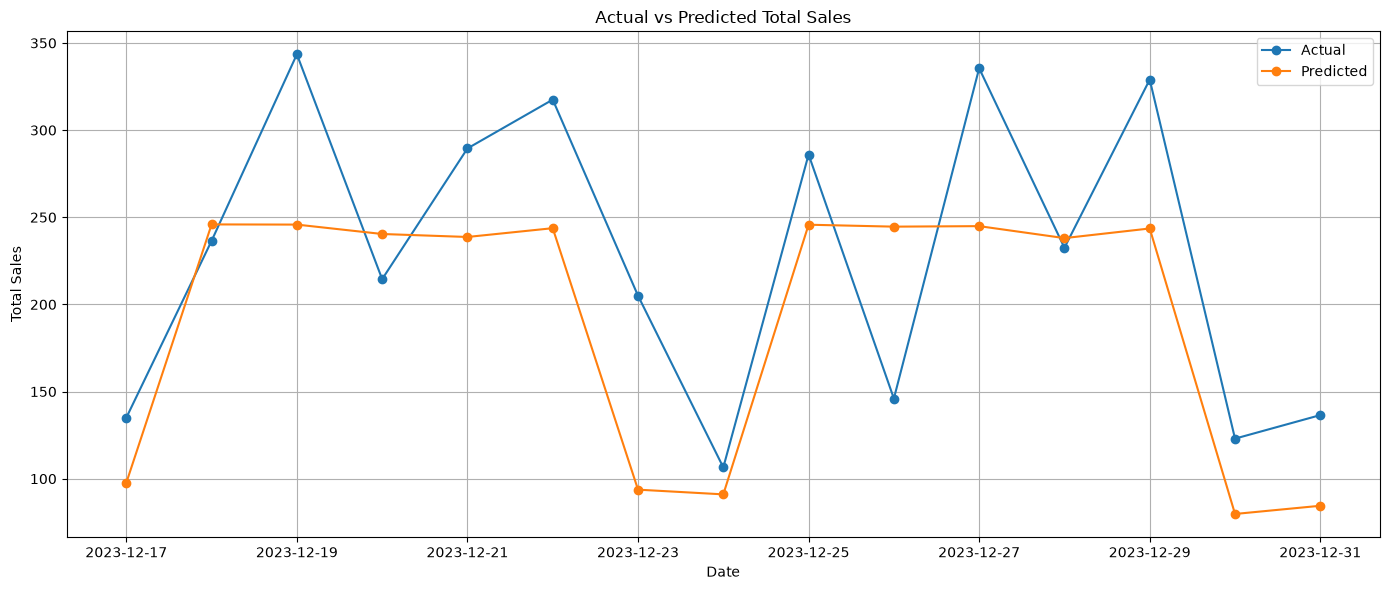

In [115]:
daily_validation_results = (
    validation_results
    .groupby("Date", as_index=False)
    .agg(
        actual_total_sales=("total_spent", "sum"),
        predicted_total_sales=("predicted_total_spent", "sum")
    )
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_validation_results["Date"],
    daily_validation_results["actual_total_sales"],
    marker="o",
    label="Actual"
)

plt.plot(
    daily_validation_results["Date"],
    daily_validation_results["predicted_total_sales"],
    marker="o",
    label="Predicted"
)

plt.title("Actual vs Predicted Total Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [116]:
feature_importance = pd.DataFrame({
    "feature": X_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
4,day_of_year,522
1,Item,268
3,day_of_month,258
11,total_spent_ma_7,223
2,day_of_week,204
0,Province,204
10,total_spent_ma_3,132
8,total_spent_lag_1,91
9,total_spent_lag_7,65
7,month,26


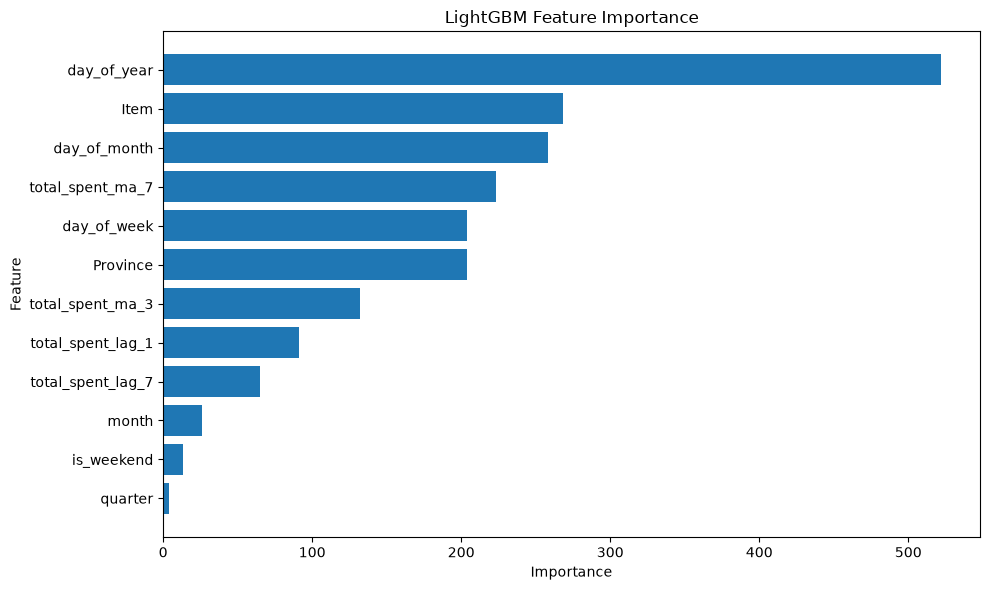

In [117]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [118]:
feature_cols_without_day_of_year = [
    col for col in feature_cols
    if col != "day_of_year"
]

X_train_no_doy = train_df[feature_cols_without_day_of_year]
X_valid_no_doy = valid_df[feature_cols_without_day_of_year]

model_no_doy = LGBMRegressor(
    objective="tweedie",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model_no_doy.fit(
    X_train_no_doy,
    y_train,
    eval_set=[(X_valid_no_doy, y_valid)],
    eval_metric="rmse",
    categorical_feature=["Province", "Item"],
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=50)
    ]
)

y_pred_no_doy = model_no_doy.predict(X_valid_no_doy)
y_pred_no_doy = np.clip(y_pred_no_doy, 0, None)

mae_no_doy = mean_absolute_error(y_valid, y_pred_no_doy)
rmse_no_doy = np.sqrt(mean_squared_error(y_valid, y_pred_no_doy))
rmsle_no_doy = np.sqrt(mean_squared_log_error(y_valid, y_pred_no_doy))

print("Without day_of_year")
print("MAE:", round(mae_no_doy, 4))
print("RMSE:", round(rmse_no_doy, 4))
print("RMSLE:", round(rmsle_no_doy, 4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002060 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 466
[LightGBM] [Info] Number of data points in the train set: 14000, number of used features: 11
[LightGBM] [Info] Start training from score 1.743226
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 10.0484	valid_0's tweedie: 8.06797
[100]	valid_0's rmse: 9.98045	valid_0's tweedie: 7.9668
[150]	valid_0's rmse: 9.93255	valid_0's tweedie: 7.95572
Early stopping, best iteration is:
[141]	valid_0's rmse: 9.93293	valid_0's tweedie: 7.95081
Without day_of_year
MAE: 5.1976
RMSE: 9.9329
RMSLE: 1.1429


In [119]:
feature_importance_no_doy = pd.DataFrame({
    "feature": feature_cols_without_day_of_year,
    "importance": model_no_doy.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_no_doy

,feature,importance
3,day_of_month,804
10,total_spent_ma_7,582
6,month,573
2,day_of_week,469
1,Item,433
9,total_spent_ma_3,382
0,Province,303
7,total_spent_lag_1,286
8,total_spent_lag_7,245
5,quarter,135


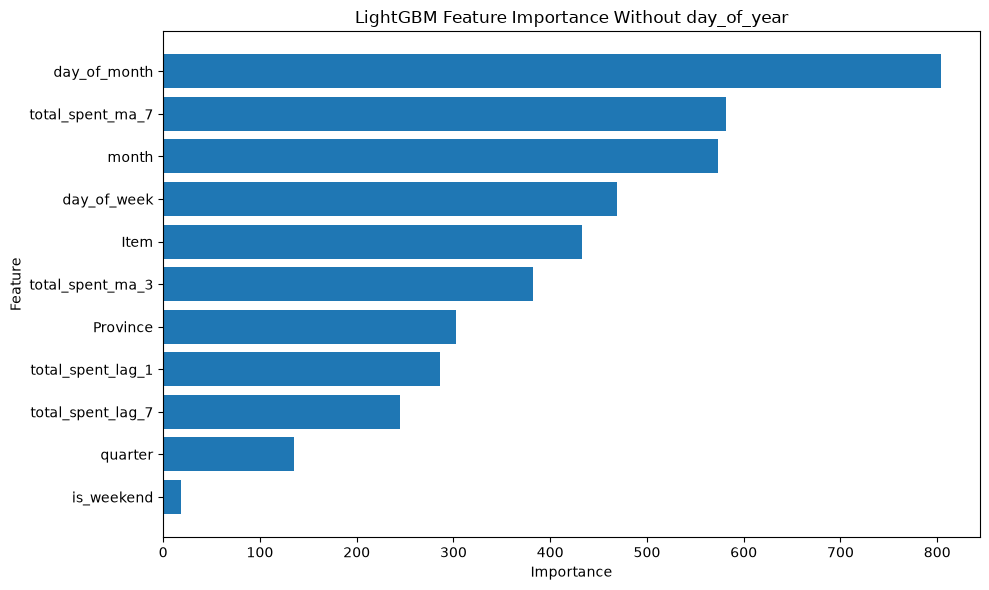

In [120]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_no_doy["feature"],
    feature_importance_no_doy["importance"]
)

plt.title("LightGBM Feature Importance Without day_of_year")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()